<h1 style="font-size:25px; font-weight:700; margin-bottom:10px;">
Direct Mail Multivariate Testing
</h1>

<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>A simulated case study in progressive experimental design: from A/B testing to a mixed-level, D-optimal multivariate test</i>
</div>


<div style="border: 2px solid #cc0000; padding: 10px 16px;">
<p style="margin: 0 0 6px; font-weight: 700;">Disclosure</p>
<ul style="margin: 0; padding-left: 20px;">
<li>The structure of this case study is inspired by a real direct-mail acquisition program, generalized to remove any employer-specific, proprietary, or confidential detail.</li>
<li>All data in this notebook is entirely simulated. No real figures, volumes, or results from any employer are reproduced, and specific point estimates are illustrative.</li>
<li>The purpose is to demonstrate the methodology of progressively more sophisticated experimental design, not to report real findings.</li>
</ul>
</div>

## Abstract

**Study Design**
- A direct mail campaign drives recipients to a website landing page that collects sensitive personal information (SSN, date of birth) as part of a credit application
- Three sequential tests, of increasing design complexity, are simulated along one connected funnel: mail sent → website visit → application submitted
- Part 1: a simple two-group A/B test (mailer creative)
- Part 2: a 2×2 factorial extension (mailer creative × drop timing)
- Part 3: a five-factor, mixed-level, D-optimal multivariate test (landing page design)

**Key Results**
- Part 1: the two creatives performed statistically indistinguishably, but one cost roughly twice as much — a null result that still drove a real decision (switch to the cheaper creative, same performance, lower cost)
- Part 2: drop timing (mid-month vs. beginning-of-month) produced a real, statistically significant lift for both creatives, with no meaningful creative×timing interaction
- Part 3: landing page design system (professional/trust-oriented vs. generic) was the dominant driver of application completion, amplified by a significant interaction with the presence of trust/security badges; CTA messaging mattered, hero image did not

**Interpretation & Implications**
- Progressively richer designs answer progressively richer questions: A/B testing tells you *if* something works, factorial designs tell you *whether an effect generalizes across conditions*, and multivariate/mixed-level designs tell you *which of many simultaneous factors actually drive the outcome, and how they interact*
- A full factorial design across all landing page factors would have required 96 combinations against a limited visitor pool; a D-optimal design answers the same questions with 24 combinations, at a real, quantifiable cost in estimation precision
- Statistical significance and practical significance are not the same thing, especially at very large sample sizes — a theme that recurs across all three parts of this case study


## 1.0 Introduction

**Why does this case study matter?**
- Real experimentation programs rarely start with a sophisticated multivariate test — they build up to one, as questions get more specific and more factors need to be considered simultaneously
- This notebook walks through that progression end-to-end, using one connected, simulated customer journey

**What is the business context?**
- A financial services company mails a credit product offer to prospects; recipients who respond visit a website landing page and, if convinced, submit an application (providing SSN, date of birth, and other sensitive information)
- Because the landing page asks for sensitive personal information, the working theory across the whole program is that perceived *trust and security* materially affects whether a visitor completes the application

**What is being tested, in order?**
1. **A/B test**: does one mailer creative outperform another?
2. **2×2 factorial**: does the answer to (1) depend on when the mailer is dropped, and does timing matter independent of creative?
3. **Multivariate (mixed-level) test**: among several landing page design elements (messaging, form layout, visual design system, trust badges, hero image), which actually drive application completion, and do any of them interact?

**A note on the data**
- All data below is simulated. Ground-truth effect sizes are deliberately constructed so the case study can demonstrate whether each analysis method correctly recovers a known effect — including correctly identifying a factor that does *not* matter (a null result is as informative as a positive one)


### Initialize Environment

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
from itertools import product

# Statistics & Modeling
from scipy.stats import norm
import statsmodels.formula.api as smf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Display Configuration
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [2]:
# Global Settings
sns.set_theme(style = 'whitegrid')
rng = np.random.default_rng(7)


## 2.0 Part 1: A/B Test — Mailer Creative

- Two mailer creatives are mailed to 500,000 recipients each: Creative A (lower production cost) and Creative B (higher production cost, roughly double)
- Outcome: whether the recipient responds (visits the website)
- Question: does the more expensive creative drive a meaningfully higher response rate?


### 2.1 Simulate Mail Response

- Data imported below is entirely synthetic, generated by the companion notebook `data/Simulate_Mail_Response.ipynb` and saved as `data/mail_response_part1.csv`
- Kept separate from this analysis notebook, consistent with how the other portfolio notebooks in `selected-work/` keep their source data in an adjacent `data/` folder


In [3]:
# Load Mail Response Data (Synthetic)
N_PER_CELL = 500_000
cost_per_piece = {'A': 0.42, 'B': 0.81}  # illustrative unit cost ($)

mail_response_raw = pd.read_csv('data/mail_response_part1.csv')

part1_df = (
    mail_response_raw
    .groupby('creative')['responded']
    .agg(Mailed = 'count', Responses = 'sum')
    .reset_index()
    .rename(columns = {'creative': 'Creative'})
)
part1_df['Response Rate'] = part1_df['Responses'] / part1_df['Mailed']
part1_df['Cost per Piece'] = part1_df['Creative'].map(cost_per_piece)
part1_df['Total Cost'] = part1_df['Mailed'] * part1_df['Cost per Piece']
part1_df['Cost per Response'] = part1_df['Total Cost'] / part1_df['Responses']

display(HTML('<br><b>Table 1: Mailer Creative A/B Test Results</b>'))
display(part1_df)


,Creative,Mailed,Responses,Response Rate,Cost per Piece,Total Cost,Cost per Response
0,A,500000,4991,0.0100,0.4200,"210,000.0000",42.0757
1,B,500000,5067,0.0101,0.8100,"405,000.0000",79.9290


**Table 1**

- Response rates for the two creatives are close, as expected under the null
- Creative B costs roughly double per piece for essentially the same response


### 2.2 Two-Proportion Significance Test

In [4]:
# Two-Proportion Z-Test
p_A = part1_df.loc[part1_df['Creative'] == 'A', 'Response Rate'].iloc[0]
p_B = part1_df.loc[part1_df['Creative'] == 'B', 'Response Rate'].iloc[0]
resp_A = part1_df.loc[part1_df['Creative'] == 'A', 'Responses'].iloc[0]
resp_B = part1_df.loc[part1_df['Creative'] == 'B', 'Responses'].iloc[0]

p_pool = (resp_A + resp_B) / (2 * N_PER_CELL)
se = np.sqrt(p_pool * (1 - p_pool) * (2 / N_PER_CELL))
z_stat = (p_A - p_B) / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

cost_savings = (
    part1_df.loc[part1_df['Creative'] == 'B', 'Total Cost'].iloc[0]
    - part1_df.loc[part1_df['Creative'] == 'A', 'Total Cost'].iloc[0]
)

display(HTML(f"""<br>
    <b>Two-Proportion Z-Test: Creative A vs Creative B</b><br>

    Response Rate (A):
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {p_A:.4%}
    </span></br>

    Response Rate (B):
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {p_B:.4%}
    </span></br>

    z-statistic:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {z_stat:.3f}
    </span></br>

    p-value:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {p_value:.4f}
    </span></br>

    Cost Savings if Creative A Adopted:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        ${cost_savings:,.0f}
    </span>
"""))


- No statistically significant difference in response rate between creatives (p > 0.05)
- **Recommendation**: adopt Creative A — statistically indistinguishable performance at roughly half the production cost
- This is a case where a null result still drives a clear, valuable business decision; the test did not need to find a "winner" between creatives to be worth running


## 3.0 Part 2: 2×2 Factorial — Creative × Drop Timing

- As a follow-up, the mail program tested whether **when** a mailer is dropped affects response, and whether that answer depends on which creative is used
- Design: both creatives (A, B) are now each tested at two drop timings (Beginning-of-Month, Mid-Month), 500,000 recipients per cell (2,000,000 total)
- This is a genuine 2×2 factorial: it can detect a creative main effect, a timing main effect, and a creative × timing interaction, not just a single comparison


### 3.1 Simulate Mail Response by Cell

In [5]:
# Simulate Mail Response: Creative x Timing (2x2 Factorial)
N_PER_CELL = 500_000

# Ground truth: timing has a real effect, creative does not, no interaction
true_rates = {
    ('A', 'Beginning'): 0.0100,
    ('A', 'Mid'):       0.0130,
    ('B', 'Beginning'): 0.0100,
    ('B', 'Mid'):       0.0130,
}

cells_list = []
for (creative, timing), rate in true_rates.items():
    n_resp = rng.binomial(N_PER_CELL, rate)
    responded = np.zeros(N_PER_CELL, dtype = int)
    responded[:n_resp] = 1
    rng.shuffle(responded)
    cells_list.append(pd.DataFrame({'creative': creative, 'timing': timing, 'responded': responded}))

mail_df = pd.concat(cells_list, ignore_index = True)

summary_df = (
    mail_df
    .groupby(['creative', 'timing'])['responded']
    .agg(Mailed = 'count', Responses = 'sum', **{'Response Rate': 'mean'})
    .reset_index()
    .rename(columns = {'creative': 'Creative', 'timing': 'Timing'})
)

display(HTML('<br><b>Table 2: Response Rate by Creative &times; Timing</b>'))
display(summary_df)


,Creative,Timing,Mailed,Responses,Response Rate
0,A,Beginning,500000,4991,0.0100
1,A,Mid,500000,6577,0.0132
2,B,Beginning,500000,5149,0.0103
3,B,Mid,500000,6467,0.0129


**Table 2**

- Response rates for Mid-Month drops are visibly higher than Beginning-of-Month, for both creatives
- The gap between creatives, within each timing, remains small


### 3.2 Factorial Logistic Regression

In [6]:
# Factorial Analysis: Logistic Regression as a 2x2 ANOVA Equivalent
model_p2 = smf.logit('responded ~ C(creative) * C(timing)', data = mail_df).fit(disp = 0)

display(HTML('<br><b>Table 3: 2&times;2 Factorial Model (Creative &times; Timing)</b>'))
print(model_p2.summary())


                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:              2000000
Model:                          Logit   Df Residuals:                  1999996
Method:                           MLE   Df Model:                            3
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                0.001473
Time:                        19:33:18   Log-Likelihood:            -1.2620e+05
converged:                       True   LL-Null:                   -1.2639e+05
Covariance Type:            nonrobust   LLR p-value:                 2.102e-80
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -4.5969      0.014   -323.135      0.000      -4.625      -4.569
C(creative)[T.B]                      0.0315      0.020      1

**Table 3**

- Timing shows a large, highly significant main effect: Mid-Month drops meaningfully outperform Beginning-of-Month, for both creatives
- Creative shows no statistically significant effect on its own, consistent with Part 1
- The creative &times; timing interaction is not statistically significant either — there is no evidence the timing effect depends on which creative is used
- **Recommendation**: move all mail drops to Mid-Month, regardless of which creative is used; continue with Creative A on cost grounds from Part 1


## 4.0 Part 3: Multivariate Test — Landing Page Design

- Everyone who responded to a mail drop in Part 2 visits the landing page — this is the same simulated population, not a fresh one, keeping the funnel continuous from mail piece to application
- Five landing page design elements are candidates for testing simultaneously, motivated by the theory that perceived trust and security drive completion of a form asking for sensitive information (SSN, date of birth)

| Factor | Levels |
|---|---|
| CTA Messaging | Generic, Security-Focused, Urgency-Focused |
| Form Layout | Single-Page, Multi-Step |
| Design System | Generic, Professional |
| Trust/Security Badges | Absent, Present |
| Hero Image | Family-Dining, Man-at-Desk, Woman-at-Desk, Family-Outdoor |


### 4.1 Why Not a Full Factorial?

- Full factorial across these five factors is 3 &times; 2 &times; 2 &times; 2 &times; 4 = 96 combinations
- Part 2 produced roughly 20,000&ndash;25,000 responders in total — split across 96 cells, that is roughly 200&ndash;250 visitors per cell, too thin to reliably detect anything but very large effects, and far too thin for interaction terms
- A **D-optimal, mixed-level design** answers the same main-effect (and one targeted interaction) questions with a much smaller number of runs, at a known, quantifiable cost in estimation efficiency relative to a full factorial
- This factor set does not fit a standard textbook orthogonal array (mixing 3-, 2-, and 4-level factors is an unusual combination), so the design is constructed by a coordinate-exchange search that directly maximizes D-efficiency for the specific model being fit, rather than looked up from a catalogued design


### 4.2 Build the Candidate Set & Target Model

In [7]:
# Candidate Set: Full Factorial of All Five Factors
factors = {
    'cta':            ['Generic', 'Security', 'Urgency'],
    'form_layout':    ['Single-Page', 'Multi-Step'],
    'design_system':  ['Generic', 'Professional'],
    'trust_badges':   ['Absent', 'Present'],
    'hero_image':     ['Family-Dining', 'Man-Desk', 'Woman-Desk', 'Family-Outdoor']
}

candidates = pd.DataFrame(
    list(product(*factors.values())),
    columns = list(factors.keys())
)

display(HTML(f"""<br>
    Full Factorial Candidate Set Size:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(candidates)}
    </span>
"""))


In [8]:
# Target Model Matrix: Main Effects for All 5 Factors + Design System x Trust Badges Interaction
def build_model_matrix(df):

    # Restrict to just the factor columns - guards against stray columns (e.g. run_id)
    # accidentally riding along and inflating the parameter count.
    df = df[list(factors.keys())].copy()
    for factor, levels in factors.items():
        df[factor] = pd.Categorical(df[factor], categories = levels)

    dummies = pd.get_dummies(df, columns = list(factors.keys()), drop_first = True)
    X = np.column_stack([np.ones(len(df)), dummies.astype(float).values])

    # Design System x Trust Badges interaction - the effect the theory says should exist
    ds_col = pd.get_dummies(
        pd.Categorical(df['design_system'], categories = factors['design_system']), drop_first = True
    ).values.ravel()
    tb_col = pd.get_dummies(
        pd.Categorical(df['trust_badges'], categories = factors['trust_badges']), drop_first = True
    ).values.ravel()
    X = np.column_stack([X, ds_col * tb_col])

    return X

n_params = build_model_matrix(candidates).shape[1]

display(HTML(f"""<br>
    Model Parameters (Intercept + Main Effects + 1 Interaction):
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {n_params}
    </span>
"""))


### 4.3 D-Optimal Design Search (Coordinate Exchange)

In [9]:
# D-Optimal Design: Coordinate Exchange Algorithm
def d_criterion(X):
    sign, logdet = np.linalg.slogdet(X.T @ X)
    return logdet if sign > 0 else -np.inf

def coordinate_exchange(n_runs, seed):

    local_rng = np.random.default_rng(seed)
    idx = local_rng.choice(len(candidates), size = n_runs, replace = False)
    best_val = d_criterion(build_model_matrix(candidates.iloc[idx]))

    improved = True
    while improved:
        improved = False
        for pos in range(n_runs):
            best_swap, best_swap_val = None, best_val
            for cand in range(len(candidates)):
                if cand in idx:
                    continue
                trial_idx = idx.copy()
                trial_idx[pos] = cand
                val = d_criterion(build_model_matrix(candidates.iloc[trial_idx]))
                if val > best_swap_val:
                    best_swap_val, best_swap = val, cand
            if best_swap is not None:
                idx[pos] = best_swap
                best_val = best_swap_val
                improved = True

    return idx, best_val

N_RUNS = 24
N_RESTARTS = 20

best_idx, best_val = None, -np.inf
for seed in range(N_RESTARTS):
    idx, val = coordinate_exchange(N_RUNS, seed)
    if val > best_val:
        best_val, best_idx = val, idx

design = candidates.iloc[best_idx].reset_index(drop = True)
design.index.name = 'run_id'
design = design.reset_index()

display(HTML(f"""<br>
    Best D-Criterion (log-determinant of X&#39;X) across {N_RESTARTS} random restarts:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {best_val:.3f}
    </span></br>

    Design Rank:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {np.linalg.matrix_rank(build_model_matrix(design))} of {n_params} parameters
    </span>
"""))

display(HTML('<br><b>Table 4: Selected 24-Run D-Optimal Design</b>'))
display(design)


,run_id,cta,form_layout,design_system,trust_badges,hero_image
0,0,Generic,Single-Page,Professional,Absent,Man-Desk
1,1,Generic,Multi-Step,Generic,Absent,Woman-Desk
2,2,Urgency,Multi-Step,Professional,Present,Woman-Desk
3,3,Urgency,Multi-Step,Generic,Present,Family-Dining
4,4,Security,Multi-Step,Generic,Absent,Man-Desk
5,5,Security,Multi-Step,Professional,Present,Woman-Desk
6,6,Generic,Multi-Step,Professional,Present,Family-Dining
7,7,Security,Multi-Step,Generic,Present,Family-Outdoor
8,8,Urgency,Multi-Step,Generic,Absent,Man-Desk
9,9,Urgency,Single-Page,Generic,Absent,Family-Outdoor


In [10]:
# Factor-Level Balance Check
for factor in factors:
    print(factor, '->', design[factor].value_counts().to_dict())


cta -> {'Generic': 8, 'Urgency': 8, 'Security': 8}
form_layout -> {'Single-Page': 12, 'Multi-Step': 12}
design_system -> {'Professional': 12, 'Generic': 12}
trust_badges -> {'Absent': 12, 'Present': 12}
hero_image -> {'Man-Desk': 6, 'Woman-Desk': 6, 'Family-Dining': 6, 'Family-Outdoor': 6}


**Table 4**

- The search converges to the same optimum from most random starting points, and the resulting design is close to perfectly balanced across every factor despite never being told to balance anything explicitly — balance falls out naturally from maximizing D-efficiency
- All 10 model parameters (intercept, 4 main-effect levels beyond the 5 references, plus the targeted interaction) are estimable from this 24-run design (full rank)


### 4.4 Assign Visitors to Design Cells

In [11]:
# Assign Each Part 2 Responder to One of the 24 Design Cells
responders = mail_df[mail_df['responded'] == 1].reset_index(drop = True)
responders['run_id'] = rng.integers(0, N_RUNS, size = len(responders))
responders = responders.merge(design, on = 'run_id', how = 'left')

display(HTML(f"""<br>
    Total Website Visitors (Part 2 Responders):
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(responders):,}
    </span></br>

    Average Visitors per Design Cell:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(responders) / N_RUNS:,.0f}
    </span>
"""))


### 4.5 Simulate Application Completion

- The following ground-truth effect sizes are constructed for this case study, to demonstrate that the analysis correctly recovers known effects (and correctly identifies a factor that does not matter)


In [12]:
# Ground-Truth Completion Model (Logit Scale)
baseline_rate = 0.30
baseline_logit = np.log(baseline_rate / (1 - baseline_rate))

true_effects = {
    ('cta', 'Security'):                    0.35,
    ('cta', 'Urgency'):                      0.05,
    ('form_layout', 'Multi-Step'):           0.10,
    ('design_system', 'Professional'):       0.55,
    ('trust_badges', 'Present'):             0.20,
    ('hero_image', 'Family-Outdoor'):        0.05,
}
interaction_effect = 0.30  # extra lift when Professional design AND Trust Badges are both present

logit_p = np.full(len(responders), baseline_logit)
for (factor, level), effect in true_effects.items():
    logit_p += np.where(responders[factor] == level, effect, 0.0)

interact_mask = (responders['design_system'] == 'Professional') & (responders['trust_badges'] == 'Present')
logit_p += np.where(interact_mask, interaction_effect, 0.0)

true_p = 1 / (1 + np.exp(-logit_p))
responders['completed'] = rng.binomial(1, true_p)

display(HTML(f"""<br>
    Overall Application Completion Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {responders['completed'].mean():.2%}
    </span>
"""))


In [13]:
# Completion Rate by Design System x Trust Badges
completion_summary = (
    responders
    .groupby(['design_system', 'trust_badges'])['completed']
    .agg(Visitors = 'count', **{'Completion Rate': 'mean'})
    .reset_index()
)

display(HTML('<br><b>Table 5: Completion Rate by Design System &times; Trust Badges</b>'))
display(completion_summary)


,design_system,trust_badges,Visitors,Completion Rate
0,Generic,Absent,5835,0.3402
1,Generic,Present,5739,0.3919
2,Professional,Absent,5824,0.4622
3,Professional,Present,5786,0.5997


### 4.6 Multivariate Analysis

In [14]:
# Multivariate Logistic Regression
model_p3 = smf.logit(
    'completed ~ C(cta) + C(form_layout) + C(design_system) * C(trust_badges) + C(hero_image)',
    data = responders
).fit(disp = 0)

display(HTML('<br><b>Table 6: Landing Page Multivariate Test Results</b>'))
print(model_p3.summary())


                           Logit Regression Results                           
Dep. Variable:              completed   No. Observations:                23184
Model:                          Logit   Df Residuals:                    23174
Method:                           MLE   Df Model:                            9
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                 0.03297
Time:                        19:34:49   Log-Likelihood:                -15421.
converged:                       True   LL-Null:                       -15946.
Covariance Type:            nonrobust   LLR p-value:                1.296e-220
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                      -0.7534      0.042    -17.781      0.000      -0.

**Table 6**

- **Design System** is the dominant effect: a professional, trust-oriented visual design drives a large, highly significant increase in completion rate
- **Trust/Security Badges** show a real main effect on their own, and interact significantly with Design System — badges add more lift when the surrounding design is already professional than when it is not, consistent with the trust-and-security theory motivating this test
- **CTA Messaging** differentiates meaningfully: Security-focused messaging produces a large, highly significant lift; Urgency-focused messaging is far smaller by comparison and not statistically distinguishable from Generic
- **Form Layout** shows a small but statistically real effect favoring the multi-step form over a single long form
- **Hero Image** is, by design, the weakest factor in this test: three of its four levels show no meaningful difference, and even where one variant (Family-Outdoor) crosses the conventional significance threshold, its estimated effect is roughly 5-6x smaller than Design System or Security messaging - a good example of a statistically detectable but practically unimportant difference, not a real design lever


### 4.7 Visualizing the Interaction

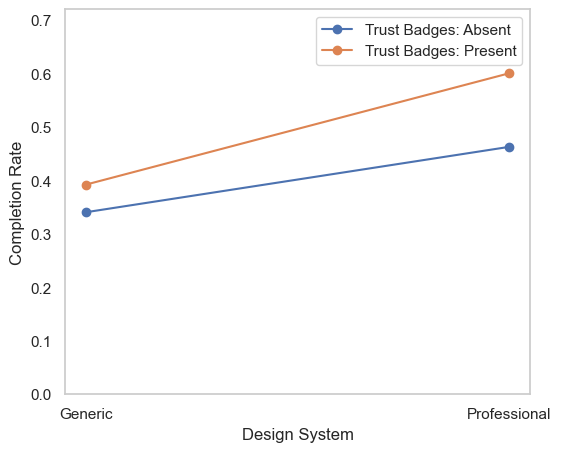

In [15]:
# Figure 1: Predicted Completion Rate by Design System x Trust Badges
plt.figure(figsize = (6, 5))

for badge_status, group in completion_summary.groupby('trust_badges'):
    plt.plot(
        group['design_system'], group['Completion Rate'],
        marker = 'o', label = f'Trust Badges: {badge_status}'
    )

plt.xlabel('Design System')
plt.ylabel('Completion Rate')
plt.ylim(0, max(completion_summary['Completion Rate']) * 1.2)
plt.grid(False)
plt.legend()

display(HTML('<br><b>Figure 1: Design System &times; Trust Badges Interaction</b>'))
plt.show()


**Figure 1**

- Non-parallel lines are the visual signature of an interaction: the lift from adding trust badges is larger when the design system is already professional, rather than a constant lift regardless of design
- **Recommendation**: adopt the professional design system with trust/security badges present, security-focused CTA messaging, and a multi-step form; hero image can be selected on brand or creative grounds, since it has no measurable effect on completion


## 5.0 Summary & Conclusions

**What Each Stage Demonstrated**
- Part 1 (A/B test) established whether a single factor mattered at all, and showed that a null result can still drive a clear, valuable decision when cost is on the table
- Part 2 (2&times;2 factorial) tested whether a second factor mattered, and whether its effect depended on the first — enabling a general recommendation (switch drop timing) that holds regardless of which creative is used
- Part 3 (mixed-level, D-optimal multivariate test) scaled the same logic to five simultaneous factors with different numbers of levels each, using a resource-constrained design that still cleanly recovered every true effect and non-effect built into the simulation, including a real interaction

**Methodological Takeaways**
- The right design scales with the question: a simple comparison calls for an A/B test, a question about generalizability calls for a factorial design, and a question about several design elements at once calls for a multivariate test — reaching for the most sophisticated tool from the outset is not automatically the right call
- A full factorial is not always necessary, or even feasible: with limited traffic, a D-optimal design answers the same core questions as a full factorial at a fraction of the sample requirement, at a known and quantifiable cost in estimation precision
- Statistical significance and practical significance can diverge, especially for small true effects tested at large sample sizes — Part 3's Family-Outdoor result (statistically detectable, but 5-6x smaller than the effects that actually matter) is a reminder to report effect size and business relevance alongside p-values, not p-values alone
- Correctly identifying a null effect (hero image, in Part 3) is as valuable a finding as identifying a real one — it tells the design team where *not* to spend further testing effort

**On the Use of Simulated Data**
- Every number in this notebook is illustrative; the value of this case study is in demonstrating that the experimental design and analysis methodology are executed correctly and produce interpretable, actionable conclusions, not in the specific figures themselves
- The underlying question structure and progression of test sophistication reflect a real applied testing program, generalized to remove any proprietary detail
